# Summary

Lets fit the models to the actual data.

---
# Setup

In [1]:
'''monkey = 'po'

behav_full = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting', f'simulation_behaviors_{monkey}.pkl'))
behav_full = behav_full[:-100_000]  # Remove last 100k rows
# count per model
print(behav_full.model.value_counts())

# save back
behav_full.to_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting', f'simulation_behaviors_{monkey}.pkl'))'''

"monkey = 'po'\n\nbehav_full = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting', f'simulation_behaviors_{monkey}.pkl'))\nbehav_full = behav_full[:-100_000]  # Remove last 100k rows\n# count per model\nprint(behav_full.model.value_counts())\n\n# save back\nbehav_full.to_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting', f'simulation_behaviors_{monkey}.pkl'))"

In [2]:
# @title Imports
import pandas as pd
import matplotlib.pyplot as plt

from popy.plotting.plotting_tools import *
from popy.behavior_data_tools import *
from popy.config import PROJECT_PATH_LOCAL

/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-cy9uyh2f because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


---
# Simulated agent behavior

In [3]:
agents_to_show = {
    'recording': 'recording',
    #'WSLS': 'WSLS',
    'Standard RL - stickiness': 'Standard RL',
    'Inferential RL - stickiness': 'Inferential RL',
    'Foraging': 'Foraging',
    #'HSMMAgent': 'HSMM',
}

# Optimization

['WSLS' 'Repeating agent' 'Standard RL - stickiness' 'Standard RL'
 'Standard RL - forgetting' 'Inferential RL - stickiness + spatial bias'
 'Standard RL - stickiness + forgetting'
 'Inferential RL - stickiness + multiple alphas' 'Foraging'
 'Inferential RL - stickiness' 'Inferential RL' 'Foraging - no reset'
 'Foraging - abandoned bias' 'Foraging - abandoned bias + spatial bias'
 'Foraging - adaptive threshold' 'HSMMAgent']


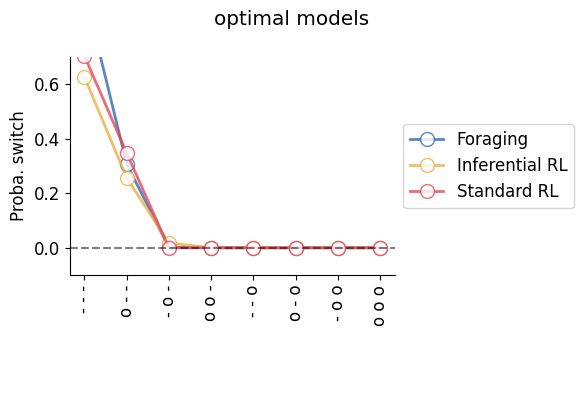

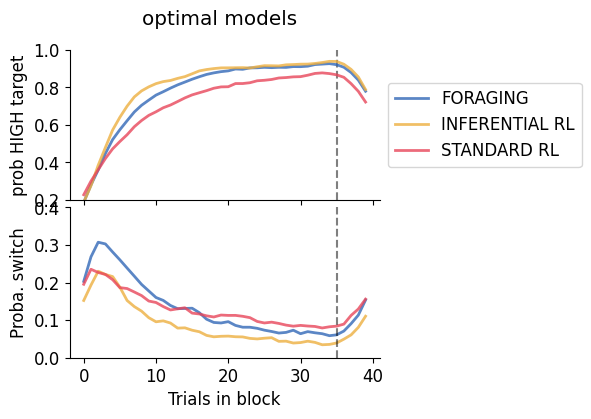

In [4]:
behav = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'optimizing', f'simulation_behaviors.pkl'))
print(behav.model.unique())
# remove n_target_touches column if exists
if 'n_target_touches' in behav.columns:
    behav = behav.drop(columns=['n_target_touches'])
# keep only models in agents_to_show.keys() and renaming them
behav = behav[behav['model'].isin(agents_to_show.keys())].copy()
behav['model'] = behav['model'].map(agents_to_show)
# rename 'recording' to 'monkey'
behav['model'] = behav['model'].replace({'recording': 'sim'})

# Apply the function to create the monkey column
behav['monkey'] = behav['model']

behav = convert_column_format(behav, original='simulation')

behav = add_history_of_feedback(behav, num_trials=3, one_column=False, coding=(0, 1))
behav = add_switch_info(behav, add_trials_since_switch=True, flip_coding=False)
behav = behav.dropna()

fig1, _ = plot_hist_thingy(behav, title=f'optimal models', paper_format=False)
# remove legend
plt.legend([], [], frameon=False)
fig2, _ = plot_strategy(behav, title=f'optimal models', paper_format=False, h=2, w=1.6, verbose=False)
# remove legend
plt.legend([], [], frameon=False)

# save figs


# Simulation

In [27]:

def plot_hist_thingy(behav_original, title=None, paper_format=False):
    labels = [ f"- - -", f"o - -" , f"- o -", f"o o -", f"- - o", f"o - o", f"- o o", f"o o o"]

    if paper_format:
        fontsize = 8
        plt.rcParams.update({'font.size': fontsize})
        h, w = 2, 1.6  # height and width in cm 
        s = 4
        lw = 1.2
    else:
        plt.rcParams.update({'font.size': 12})
        h, w = 4, 6
        s = 10
        lw = 2

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(w, h), gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})

    if title is not None:
        fig.suptitle(title)

    ax = ax1

    for i, (monkey, behav_data) in enumerate(behav_original.groupby('monkey')):
        behav = behav_data.copy()

        #balance for shifts (random undersampling majority class)
        '''n_switch = np.sum(behav['switch'])
        n_no_switch = len(behav) - n_switch
        n_minority = int(np.min([n_switch, n_no_switch]))
        behav = behav.groupby('switch').apply(lambda x: x.sample(n=n_minority, random_state=42)).reset_index(drop=True)'''

        # downsample each groups
        comb_counts = behav.groupby(['R_1', 'R_2', 'R_3']).size().reset_index(name='counts')
        min_count = comb_counts['counts'].min()  # Determine the minimum count among the combinations
        # Function to undersample each combination
        def undersample(group):
            return group.sample(n=min_count, random_state=42)
        behav = behav.groupby(['R_1', 'R_2', 'R_3']).apply(undersample).reset_index(drop=True)  # Apply undersampling

        all_trials_vector = []
        for (R_1, R_2, R_3), behav_temp in behav.groupby(['R_1', 'R_2', 'R_3']):
            all_trials_vector.append(behav_temp['switch'].mean())

        # Check if monkey name ends with _short to use dashed line
        if monkey.endswith('_short'):
            linestyle = 'dashed'
            monkey_base = monkey[:-6]  # Remove '_short' suffix
        else:
            linestyle = 'solid'
            monkey_base = monkey
            
        color = COLORS[monkey_base] if monkey_base in COLORS else 'grey'
        ax.plot(all_trials_vector, label=f'{monkey}',
                color=color, 
                alpha=.8,
                linestyle=linestyle,
                markerfacecolor=color if monkey_base in ['ka', 'po', 'yu_DCZ', 'yu_sham'] else 'white',
                marker='*' if monkey_base in ['ka', 'po', 'yu_DCZ', 'yu_sham'] else 'o',
                zorder=0 if monkey_base in ['ka', 'po', 'yu_DCZ', 'yu_sham'] else 10,
                markersize=s*2 if monkey_base in ['ka', 'po', 'yu_DCZ', 'yu_sham'] else s,
                linewidth=lw)# if not monkey in ['ka', 'po', 'yu_DCZ', 'yu_sham'] else lw*2, alpha=0.8)

    ax.axhline(0, color='black', linestyle='-', alpha=1, linewidth=1)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=90)

    ax.set_xlabel('')
    ax.set_ylim(-0.02, .7)
    ax.set_ylabel('Proba. switch')

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # legend to the right
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)

    ax = ax2
    # just a transparent axis
    ax.axis('off')

    '''ax = ax2
    for i, label in enumerate(labels):
        for j, marker in enumerate(label.split(' ')):        
            ax.scatter(i, j, marker='o' if marker == 'o' else 'x', c='tab:green' if marker == 'o' else 'tab:red')

    #ax.set_xticks([])

    ax.set_yticks([0,1,2])
    ax.set_yticklabels(['t-3', 't-2', 't-1'])
    ax.set_ylim(-1, 3)

    ax.set_ylabel('past trials')

    # make legend: o for rewarded, x for unrewarded
    ax.scatter([], [], color="tab:green", marker="o", label="Rewarded")
    ax.scatter([], [], color="tab:red", marker="x", label="Unrewarded")
    ax.legend(loc='lower center', bbox_to_anchor=(0.8, -0.5), ncol=1)

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)'''

    if not paper_format:
        plt.tight_layout()

    return fig, (ax1, ax2)
  

Processing monkey: ka


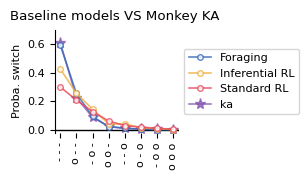

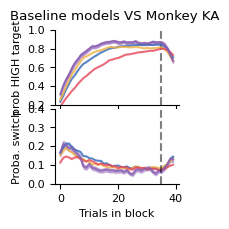

Processing monkey: po


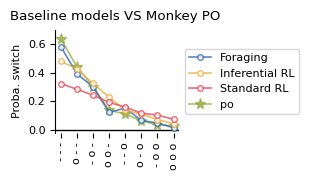

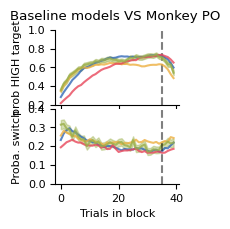

In [28]:
for monkey in ['ka', 'po']:#, 'yu_sham', 'yu_DCZ']:
    print(f'Processing monkey: {monkey}')
    behav = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting_no_cv', f'simulation_behaviors_{monkey}.pkl'))

    # remove n_target_touches column if exists
    if 'n_target_touches' in behav.columns:
        behav = behav.drop(columns=['n_target_touches'])
    # keep only models in agents_to_show.keys() and renaming them
    behav = behav[behav['model'].isin(agents_to_show.keys())].copy()
    behav['model'] = behav['model'].map(agents_to_show)
    # rename 'recording' to 'monkey'
    behav['model'] = behav['model'].replace({'recording': monkey})

    # Apply the function to create the monkey column
    behav['monkey'] = behav['model']

    behav = convert_column_format(behav, original='simulation')

    behav = add_history_of_feedback(behav, num_trials=3, one_column=False, coding=(0, 1))
    behav = add_switch_info(behav, add_trials_since_switch=True, flip_coding=False)
    behav = behav.dropna()
    
    fig1, _ = plot_hist_thingy(behav, title=f'Baseline models VS Monkey {monkey.upper()}', paper_format=True)
    # remove legend
    plt.legend([], [], frameon=False)
    fig2, _ = plot_strategy(behav, title=f'Baseline models VS Monkey {monkey.upper()}', paper_format=True, h=2, w=1.6, verbose=False)
    # remove legend
    plt.legend([], [], frameon=False)

    # save figs
    fig1.savefig(f'figs/behav_modeling_{monkey}_history_thing.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig1)
    fig2.savefig(f'figs/behav_modeling_{monkey}_strategy.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig2)

# Plotting the fitting results on the first 15 trials only against the full fitting

Processing monkey: ka


TypeError: plot_strategy() got an unexpected keyword argument 'ylim'

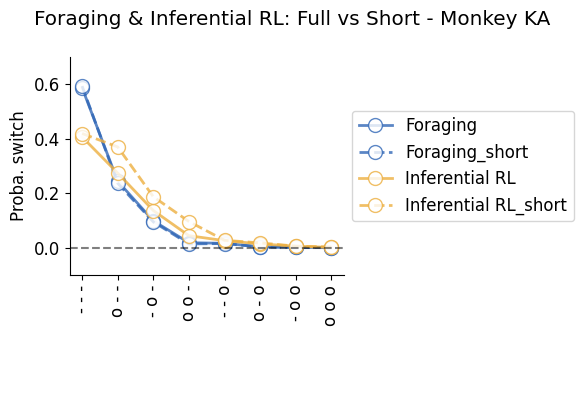

In [6]:
# Filter and prepare data for both model sets
models_to_plot = {
    'Inferential RL - stickiness': 'Inferential RL',
    'Foraging': 'Foraging',
}

for monkey in ['ka', 'po']:
    print(f'Processing monkey: {monkey}')
    
    # Load both datasets
    behav_full = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting', f'simulation_behaviors_{monkey}.pkl'))
    behav_first15 = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting_first15', f'simulation_behaviors_{monkey}.pkl'))
    
    # Process full dataset
    behav_original = behav_full.copy()
    if 'n_target_touches' in behav_original.columns:
        behav_original = behav_original.drop(columns=['n_target_touches'])
    behav_original = behav_original[behav_original['model'].isin(models_to_plot.keys())].copy()
    behav_original['model'] = behav_original['model'].map(models_to_plot)
    behav_original['monkey'] = behav_original['model']
    behav_original = convert_column_format(behav_original, original='simulation')
    behav_original = add_history_of_feedback(behav_original, num_trials=3, one_column=False, coding=(0, 1))
    behav_original = add_switch_info(behav_original, add_trials_since_switch=True, flip_coding=False)
    behav_original = behav_original.dropna()
    
    # Process the second set of models (fitting_first15) and rename them with _short suffix
    behav_short = behav_first15.copy()
    if 'n_target_touches' in behav_short.columns:
        behav_short = behav_short.drop(columns=['n_target_touches'])
    behav_short = behav_short[behav_short['model'].isin(models_to_plot.keys())].copy()
    behav_short['model'] = behav_short['model'].map(models_to_plot)
    behav_short['model'] = behav_short['model'] + '_short'
    behav_short['monkey'] = behav_short['model']
    behav_short = convert_column_format(behav_short, original='simulation')
    behav_short = add_history_of_feedback(behav_short, num_trials=3, one_column=False, coding=(0, 1))
    behav_short = add_switch_info(behav_short, add_trials_since_switch=True, flip_coding=False)
    behav_short = behav_short.dropna()
    
    # Combine both datasets
    behav_combined = pd.concat([behav_original, behav_short], ignore_index=True)
    
    # Plot
    fig1, _ = plot_hist_thingy(behav_combined, title=f'Foraging & Inferential RL: Full vs Short - Monkey {monkey.upper()}', paper_format=False)
    fig2, _ = plot_strategy(behav_combined, title=f'Foraging & Inferential RL: Full vs Short - Monkey {monkey.upper()}', paper_format=False, h=2, w=1.6, ylim=[0, .4], verbose=False)
    
    # save figs
    fig1.savefig(f'figs/behav_modeling_{monkey}_short_comparison_history.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig1)
    fig2.savefig(f'figs/behav_modeling_{monkey}_short_comparison_strategy.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig2)

# Plotting the fitting results on the first 10 trials only against the full fitting

Processing monkey: ka


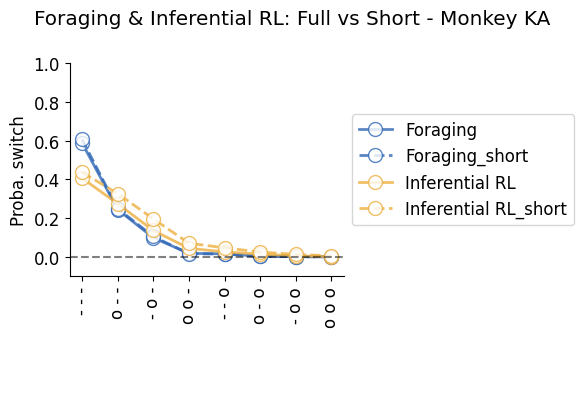

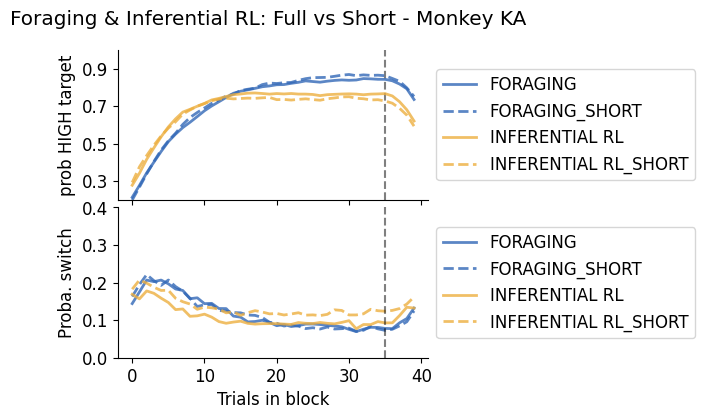

Processing monkey: po


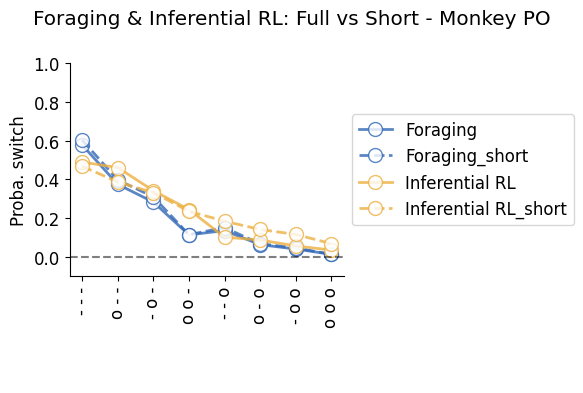

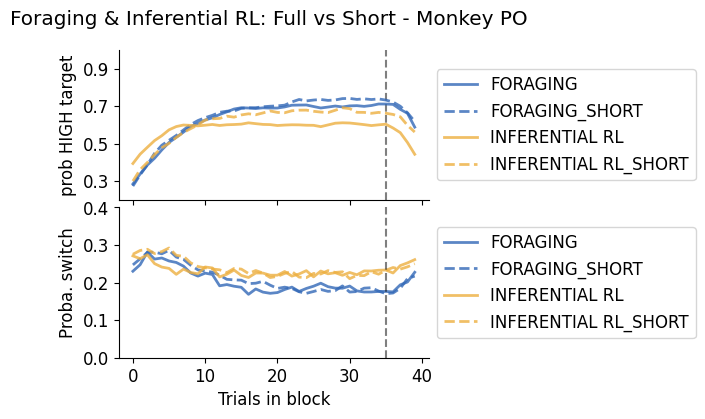

In [ ]:
# Filter and prepare data for both model sets
models_to_plot = {
    'Inferential RL - stickiness': 'Inferential RL',
    'Foraging': 'Foraging',
}

for monkey in ['ka', 'po']:
    print(f'Processing monkey: {monkey}')
    
    # Load both datasets
    behav_full = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting', f'simulation_behaviors_{monkey}.pkl'))
    behav_first10 = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting_first10', f'simulation_behaviors_{monkey}.pkl'))
    
    # Process full dataset
    behav_original = behav_full.copy()
    if 'n_target_touches' in behav_original.columns:
        behav_original = behav_original.drop(columns=['n_target_touches'])
    behav_original = behav_original[behav_original['model'].isin(models_to_plot.keys())].copy()
    behav_original['model'] = behav_original['model'].map(models_to_plot)
    behav_original['monkey'] = behav_original['model']
    behav_original = convert_column_format(behav_original, original='simulation')
    behav_original = add_history_of_feedback(behav_original, num_trials=3, one_column=False, coding=(0, 1))
    behav_original = add_switch_info(behav_original, add_trials_since_switch=True, flip_coding=False)
    behav_original = behav_original.dropna()
    
    # Process the second set of models (fitting_first10) and rename them with _short suffix
    behav_short = behav_first10.copy()
    if 'n_target_touches' in behav_short.columns:
        behav_short = behav_short.drop(columns=['n_target_touches'])
    behav_short = behav_short[behav_short['model'].isin(models_to_plot.keys())].copy()
    behav_short['model'] = behav_short['model'].map(models_to_plot)
    behav_short['model'] = behav_short['model'] + '_short'
    behav_short['monkey'] = behav_short['model']
    behav_short = convert_column_format(behav_short, original='simulation')
    behav_short = add_history_of_feedback(behav_short, num_trials=3, one_column=False, coding=(0, 1))
    behav_short = add_switch_info(behav_short, add_trials_since_switch=True, flip_coding=False)
    behav_short = behav_short.dropna()
    
    # Combine both datasets
    behav_combined = pd.concat([behav_original, behav_short], ignore_index=True)
    
    # Plot
    fig1, _ = plot_hist_thingy(behav_combined, title=f'Foraging & Inferential RL: Full vs Short - Monkey {monkey.upper()}', paper_format=False)
    fig2, _ = plot_strategy(behav_combined, title=f'Foraging & Inferential RL: Full vs Short - Monkey {monkey.upper()}', paper_format=False, h=2, w=1.6, ylim=[0, .4], verbose=False)
    
    # save figs
    fig1.savefig(f'figs/behav_modeling_{monkey}_short_comparison_history.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig1)
    fig2.savefig(f'figs/behav_modeling_{monkey}_short_comparison_strategy.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig2)